In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [6]:
df = pd.read_csv('../data/raw/transactions.csv')

In [7]:
df.head()

,transaction_id,customer_id,kyc_verified,account_age_days,transaction_amount,channel,timestamp,is_fraud
0,TXN_200000,CUST_799,Yes,1050,256369,Mobile,2025-08-12 02:10:24,0
1,TXN_200001,CUST_484,Yes,295,6581,Mobile,2025-08-25 01:14:31,0
2,TXN_200002,CUST_791,Yes,2083,4492,Mobile,2025-08-17 12:12:40,0
3,TXN_200003,CUST_664,Yes,2789,275413,POS,2025-08-07 06:23:54,0
4,TXN_200004,CUST_157,Yes,694,98098,POS,2025-08-20 21:55:54,0


In [8]:
df.shape

(5000, 8)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   transaction_id      5000 non-null   object
 1   customer_id         5000 non-null   object
 2   kyc_verified        5000 non-null   object
 3   account_age_days    5000 non-null   int64 
 4   transaction_amount  5000 non-null   int64 
 5   channel             5000 non-null   object
 6   timestamp           5000 non-null   object
 7   is_fraud            5000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 312.6+ KB


In [10]:
df.describe()

,account_age_days,transaction_amount,is_fraud
count,5000.000000,5000.000000,5000.000000
mean,1498.906400,39283.321000,0.086400
std,867.615096,70330.374967,0.280982
min,10.000000,1054.000000,0.000000
25%,732.000000,6000.500000,0.000000
50%,1481.500000,9670.000000,0.000000
75%,2254.250000,20324.750000,0.000000
max,2999.000000,299992.000000,1.000000


In [11]:
df.isnull().sum()

transaction_id        0
customer_id           0
kyc_verified          0
account_age_days      0
transaction_amount    0
channel               0
timestamp             0
is_fraud              0
dtype: int64

In [12]:
df.fillna({"kyc_verified": "No"}, inplace=True)

In [13]:
df.dropna(subset=["transaction_amount"], inplace=True)

In [17]:
df.duplicated().sum()

0

In [18]:
df.drop_duplicates(subset="transaction_id", inplace=True)

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['channel'] = df['channel'].str.title()
df['transaction_amount'] = df['transaction_amount'].astype(float)

In [21]:
df['hour'] = df['timestamp'].dt.hour
df['weekday'] = df['timestamp'].dt.weekday
df['is_high_value'] = (df['transaction_amount'] > 50000).astype(int)

In [22]:
df.sample(6)

,transaction_id,customer_id,kyc_verified,account_age_days,transaction_amount,channel,timestamp,is_fraud,hour,weekday,is_high_value
3527,TXN_203527,CUST_106,Yes,2674,16727.0,Web,2025-08-23 00:29:38,0,0,5,0
4051,TXN_204051,CUST_786,Yes,2710,11886.0,Mobile,2025-08-19 21:42:39,0,21,1,0
2910,TXN_202910,CUST_603,Yes,152,5127.0,Mobile,2025-08-10 16:28:58,0,16,6,0
1788,TXN_201788,CUST_739,Yes,429,193993.0,Web,2025-08-17 11:04:57,0,11,6,1
1489,TXN_201489,CUST_564,Yes,2213,15591.0,Mobile,2025-08-23 18:30:03,0,18,5,0
96,TXN_200096,CUST_771,Yes,1546,9152.0,Web,2025-08-12 14:52:09,0,14,1,0


In [24]:
# Save processed data
df.to_csv('../data/processed/transactions_processed.csv', index=False)

# EDA

In [26]:
# Fraud % vs Legit %
fraud_counts = df['is_fraud'].value_counts(normalize=True) * 100
print("Fraud %:", fraud_counts.get(1, 0))
print("Legit %:", fraud_counts.get(0, 0))

Fraud %: 8.64
Legit %: 91.36


In [27]:
# Avg amount in fraud vs non-fraud
avg_amounts = df.groupby('is_fraud')['transaction_amount'].mean()
print("Avg amount (Fraud):", avg_amounts.get(1, 0))
print("Avg amount (Legit):", avg_amounts.get(0, 0))

Avg amount (Fraud): 87011.64351851853
Avg amount (Legit): 34769.60923817864


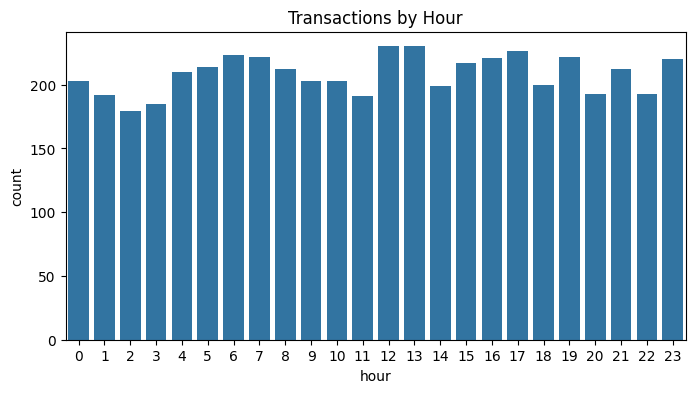

In [28]:
# Transactions by hour
plt.figure(figsize=(8,4))
sns.countplot(x='hour', data=df)
plt.title('Transactions by Hour')
plt.show()

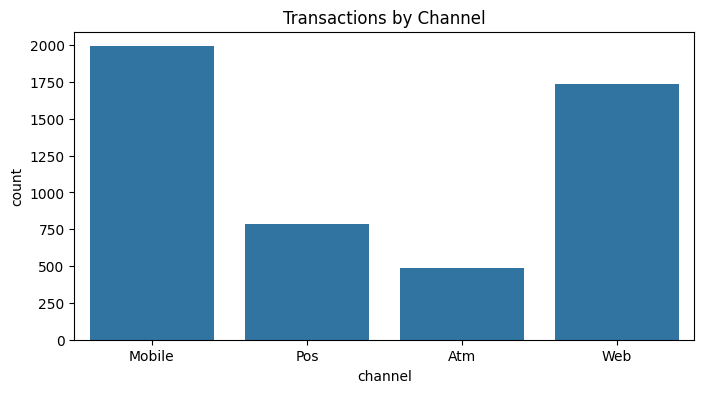

In [29]:
# Transactions by channel
plt.figure(figsize=(8,4))
sns.countplot(x='channel', data=df)
plt.title('Transactions by Channel')
plt.show()

In [31]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, stratify=df['is_fraud'], random_state=42)

train.to_csv("../data/processed/train.csv", index=False)
test.to_csv("../data/processed/test.csv", index=False)